## Training LoRA

In [7]:
!pip install -q -U boto3 chromadb open_clip_torch bitsandbytes peft transformers accelerate

In [82]:
# Importing useful dependencies
import io
import os
import time
import torch
import boto3
import random
import tarfile
import chromadb
import functools
import open_clip
import numpy as np
import pandas as pd
import torch.nn as nn
from PIL import Image
from io import BytesIO
import torch.optim as optim
import matplotlib.pyplot as plt
from typing import List, Tuple
import torch.nn.functional as F
from torchvision import transforms
from open_clip.loss import ClipLoss
from chromadb.config import Settings
from tempfile import TemporaryDirectory
from torch.cuda.amp import autocast, GradScaler
from peft import LoraConfig, get_peft_model, TaskType
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import CLIPProcessor, CLIPModel, BitsAndBytesConfig

# Set a seed for reproducibility
def set_seed(SEED=42):
  random.seed(SEED)
  np.random.seed(SEED)
  torch.manual_seed(SEED)
  torch.cuda.manual_seed_all(SEED)

set_seed(10721)

In this notebook, we fine-tune the pretrained CLIP model **ViT-L/16** using the training data prepared in the previous Zone.

We begin by splitting the dataset into **train**, **development (dev)**, and **test** sets. During fine-tuning, **only the training set** will be used to update the model parameters. After training is complete, the **dev set** will be used for a quick evaluation to verify whether the model generalizes properly. The **test set** will be held out entirely and will not be used until the next Zone.

In [73]:
# Setup S3 client for MinIO (MinIO implements Amazon S3 API)
s3 = boto3.client(
    "s3",
    #endpoint_url="http://127.0.0.1:9000", # MinIO API endpoint
    endpoint_url="https://uneradicable-plushest-terrilyn.ngrok-free.dev", # MinIO API endpoint (ngrok)
    aws_access_key_id="minioadmin", # User name
    aws_secret_access_key="minioadmin", # Password
)

In [94]:
# Just in case our device has gpu
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch16",
    dtype=torch.float32,
    device_map="cuda"
)
# Load the processor (handles tokenization + image preprocessing)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch16")

In [32]:
# ---- Show parameter counts ----
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model: CLIP-ViT-B-16")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"The parameters are in: {str(next(model.parameters()).dtype)}")

Model: CLIP-ViT-B-16
Total parameters: 149,620,737
Trainable parameters: 149,620,737
The parameters are in: torch.float32


In this notebook, we will fine-tune the model using LoRA. The main body of the model will be frozen, and only the key fully-connected (FC) layers will be trained.

In [95]:
# LoRA configuration TEXT
lora_config_text = LoraConfig(
    task_type=TaskType.FEATURE_EXTRACTION, # for the text encoder
    r=8,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.1,
    bias="none"
)
# LoRA configuration IMAGE
lora_config_image = LoraConfig(
    task_type=TaskType.FEATURE_EXTRACTION, # for the image encoder
    r=8,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.1,
    bias="none"
)
# --- Safe wrapper to filter allowed arguments ---
class LoRACLIPWrapper(nn.Module):
    def __init__(self, model, model_type="vision"):
        super().__init__()
        self.model = model
        self.model_type = model_type

    def forward(self, **kwargs):
        if self.model_type == "vision":
            # call CLIPVisionTransformer normally and return the BaseModelOutput
            pixel_values = kwargs.get("pixel_values")
            return self.model.forward(pixel_values=pixel_values)
        elif self.model_type == "text":
            input_ids = kwargs.get("input_ids")
            attention_mask = kwargs.get("attention_mask", None)
            return self.model.forward(input_ids=input_ids, attention_mask=attention_mask)
        else:
            raise ValueError("model_type must be 'vision' or 'text'")

# Wrap text encoder
model.text_model = get_peft_model(LoRACLIPWrapper(model.text_model, model_type="text"), lora_config_text)
# Wrap image encoder
model.vision_model = get_peft_model(LoRACLIPWrapper(model.vision_model, model_type="vision"), lora_config_image)

In [34]:
# ---- Show parameter counts ----
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model: CLIP-ViT-B-16 (LoRA)")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"The parameters are in: {str(next(model.parameters()).dtype)}")

Model: CLIP-ViT-B-16 (LoRA)
Total parameters: 150,112,257
Trainable parameters: 1,146,881
The parameters are in: torch.float32


The LoRA adapters added only a small number of parameters, while significantly reducing the portion of the model that needs to be trained.

### Dataloader

In [14]:
# Customized Dataloader class for our project
class ImageTextDataset(Dataset):
    def __init__(self, data_bucket, data_prefix, s3):
        self.data_bucket = data_bucket
        self.data_prefix = data_prefix
        self.s3 = s3

        # Data keys
        self.image_keys, self.text_keys = self.__loadfromminio__(data_bucket, data_prefix)

    def __loadfromminio__(self, data_bucket, data_prefix):
        image_keys = []
        text_keys = []
        paginator = self.s3.get_paginator("list_objects_v2")
        for page in paginator.paginate(Bucket=data_bucket, Prefix=data_prefix):
            for obj in page.get("Contents", []):
                  key = obj["Key"]
                  if obj['Size'] == 0 and key.endswith("/"):
                      continue
                  if "image" in key.split("/")[1]: # We only need images to find their corresponding description in MinIO
                      image_keys.append(key)
                      text_key = data_prefix + key.split("/")[1].replace("image", "text").replace("png", "txt")
                      text_keys.append(text_key)

        # From lists to arrays
        image_keys = np.array(image_keys)
        text_keys = np.array(text_keys)

        return image_keys, text_keys

    def __len__(self):
        return len(self.image_keys)

    def __getfile__(self, data_bucket, key, filetype = "image"):
        resp = self.s3.get_object(Bucket=data_bucket, Key=key)
        body = resp["Body"].read()
        if filetype == "image":
            file = Image.open(BytesIO(body))
        else: # filetype = "text"
            file = body.decode("utf-8")
        return file

    def __getitem__(self, idx):

        # Load image
        image = self.__getfile__(self.data_bucket, self.image_keys[idx], filetype = "image")

        # Load text
        text = self.__getfile__(self.data_bucket, self.text_keys[idx], filetype = "text")

        return image, text

# Collate function that applies preprocess and tokenizer to the batch
def collate_fn(batch: List[Tuple[Image.Image, str]], processor: CLIPProcessor):
    """
    batch: list of (PIL.Image, text_str)
    processor: Hugging Face CLIPProcessor
    Returns:
        images: torch.Tensor [B, C, H, W]
        input_ids: torch.LongTensor [B, L]
        attention_mask: torch.LongTensor [B, L]
        raw_texts: list[str]
    """
    images_pil, raw_texts = zip(*batch)

    # Use processor to handle both images and text
    processed = processor(
        text=list(raw_texts),
        images=list(images_pil),
        return_tensors="pt",
        padding=True,
        truncation=True,   # ensure sequences do not exceed max length
        max_length=77      # CLIP default
    )

    return (
        processed['pixel_values'],   # tensor [B, C, H, W]
        processed['input_ids'],      # tensor [B, L]
        processed['attention_mask'], # tensor [B, L]
        list(raw_texts)              # original texts
    )

# Wrap for DataLoader
collate = functools.partial(collate_fn, processor=processor)

Next, we create a Dataloader object for each of the training data.

In [74]:
# Create customized dataset objects
baseline_dataset = ImageTextDataset(
    data_bucket = "training-data-construction-zone",
    data_prefix = "baseline-training-data/",
    s3 = s3
)
augmented_1_dataset = ImageTextDataset(
    data_bucket = "training-data-construction-zone",
    data_prefix = "text_augmented-training-data/",
    s3 = s3
)
augmented_2_dataset = ImageTextDataset(
    data_bucket = "training-data-construction-zone",
    data_prefix = "image_augmented-training-data/",
    s3 = s3
)
augmented_3_dataset = ImageTextDataset(
    data_bucket = "training-data-construction-zone",
    data_prefix = "text_image_augmented-training-data/",
    s3 = s3
)

The data split is performed in the next cell. First, **80% of the full dataset** is allocated for training, while the remaining **20% is reserved for testing**. Then, the training portion is further divided: **80% is used for actual training**, and the remaining **20% is used as the development set**.

In [75]:
# Given the size of a dataset, the function returns the splits
def get_set_sizes(dataset_size):
  train_size = int(0.64 * dataset_size) # 0.8 * 0.8 = 0.64
  dev_size = int(0.16 * dataset_size) # 0.8 * 0.2 = 0.16
  test_size = dataset_size - train_size - dev_size # 0.2
  return [train_size, dev_size, test_size]

set_seed(10721)
# Split the training data into train/dev/test sets, the test sets won't be used in this notebook
base_train_dataset, base_dev_dataset, _ = random_split(baseline_dataset, get_set_sizes(len(baseline_dataset)))
aug1_train_dataset, aug1_dev_dataset, _ = random_split(augmented_1_dataset, get_set_sizes(len(augmented_1_dataset)))
aug2_train_dataset, aug2_dev_dataset, _ = random_split(augmented_2_dataset, get_set_sizes(len(augmented_2_dataset)))
aug3_train_dataset, aug3_dev_dataset, _ = random_split(augmented_3_dataset, get_set_sizes(len(augmented_3_dataset)))

In [76]:
set_seed(10721)
# Apply a shuffle over the dataset to prevent the model from learning order-based patterns
dataloader0 = DataLoader(base_train_dataset, batch_size=8, shuffle=True, collate_fn=collate, num_workers=0)
dataloader1 = DataLoader(aug1_train_dataset, batch_size=8, shuffle=True, collate_fn=collate, num_workers=0)
dataloader2 = DataLoader(aug2_train_dataset, batch_size=8, shuffle=True, collate_fn=collate, num_workers=0)
dataloader3 = DataLoader(aug3_train_dataset, batch_size=8, shuffle=True, collate_fn=collate, num_workers=0)
# Increasing the size of the batch slows down the training process, but generalizes better the model

In [67]:
# Create a model for all cases
model_0 = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch16",
    dtype=torch.float32,
    device_map="cuda"
)
model_0.text_model = get_peft_model(LoRACLIPWrapper(model_0.text_model, model_type="text"), lora_config_text) # Wrap text encoder
model_0.vision_model = get_peft_model(LoRACLIPWrapper(model_0.vision_model, model_type="vision"), lora_config_image) # Wrap image encoder

model_1 = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch16",
    dtype=torch.float32,
    device_map="cuda"
)
model_1.text_model = get_peft_model(LoRACLIPWrapper(model_1.text_model, model_type="text"), lora_config_text) # Wrap text encoder
model_1.vision_model = get_peft_model(LoRACLIPWrapper(model_1.vision_model, model_type="vision"), lora_config_image) # Wrap image encoder

model_2 = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch16",
    dtype=torch.float32,
    device_map="cuda"
)
model_2.text_model = get_peft_model(LoRACLIPWrapper(model_2.text_model, model_type="text"), lora_config_text) # Wrap text encoder
model_2.vision_model = get_peft_model(LoRACLIPWrapper(model_2.vision_model, model_type="vision"), lora_config_image) # Wrap image encoder

model_3 = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch16",
    dtype=torch.float32,
    device_map="cuda"
)
model_3.text_model = get_peft_model(LoRACLIPWrapper(model_3.text_model, model_type="text"), lora_config_text) # Wrap text encoder
model_3.vision_model = get_peft_model(LoRACLIPWrapper(model_3.vision_model, model_type="vision"), lora_config_image) # Wrap image encoder

### Fine-tuning

In [68]:
# The function trains the model given the model and the dataloader
def fine_tune(model, dataloader, epochs=1):

  criterion = ClipLoss()

  # Test fine-tuning on ViT-B-16 with Mixed/Reduced Precision (FP16)

  losses = [] # Store losses
  latencies = [] # ms per iteration
  throughputs = [] # samples per second
  gpu_mem_usage = [] # GB

  # AdamW optimizer
  optimizer = optim.AdamW(model.parameters(), lr=1e-6)
  # Big lr leads to overfitting on the training data ->
  # the model will get better results on the training data, but poor results on the test set

  for epoch in range(1, epochs + 1):

    print(f"\n===== Epoch {epoch} / {epochs} =====")

    for images, input_ids, attention_mask, raw_texts in dataloader:
      # Move to device
      images = images.to(device)
      input_ids = input_ids.to(device)
      attention_mask = attention_mask.to(device)

      batch_size = images.size(0)
      torch.cuda.reset_peak_memory_stats(device)
      start_time = time.perf_counter()
      optimizer.zero_grad()

      # Clamp logit scale to avoid overflow
      with torch.no_grad():
          model.logit_scale.data = model.logit_scale.data.clamp(max=1.5)

      # Forward pass
      img_feats = model.get_image_features(images)
      txt_feats = model.get_text_features(
          input_ids=input_ids,
          attention_mask=attention_mask
      )
      loss = criterion(img_feats, txt_feats, model.logit_scale.exp())

      # Backward
      loss.backward()

      # Gradient clipping
      torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

      # Optimizer step
      optimizer.step()

      torch.cuda.synchronize(device)
      end_time = time.perf_counter()

      # Metrics
      latency_ms = (end_time - start_time) * 1000
      throughput = batch_size / (end_time - start_time)
      peak_mem_gb = torch.cuda.max_memory_allocated(device) / 1e9

      # Append metrics
      losses.append(loss.item())
      latencies.append(latency_ms)
      throughputs.append(throughput)
      gpu_mem_usage.append(peak_mem_gb)

      print(
          f"Loss: {loss.item():.4f} | "
          f"Latency: {latency_ms:.2f} ms | "
          f"Throughput: {throughput:.2f} samples/s | "
          f"GPU Mem: {peak_mem_gb:.2f} GB"
      )

  # ----- Plot metrics -----
  fig, axes = plt.subplots(2, 2, figsize=(14,10))

  axes[0, 0].plot(losses, marker='o')
  axes[0, 0].set_title("Training Loss")
  axes[0, 0].set_xlabel("Iteration")
  axes[0, 0].set_ylabel("Loss")
  axes[0, 0].grid(True)

  axes[0, 1].plot(latencies, marker='o')
  axes[0, 1].set_title("Latency per Iteration (ms)")
  axes[0, 1].set_xlabel("Iteration")
  axes[0, 1].set_ylabel("Latency (ms)")
  axes[0, 1].grid(True)

  axes[1, 0].plot(throughputs, marker='o')
  axes[1, 0].set_title("Throughput (samples/s)")
  axes[1, 0].set_xlabel("Iteration")
  axes[1, 0].set_ylabel("Samples / second")
  axes[1, 0].grid(True)

  axes[1, 1].plot(gpu_mem_usage, marker='o')
  axes[1, 1].set_title("Peak GPU Memory Usage (GB)")
  axes[1, 1].set_xlabel("Iteration")
  axes[1, 1].set_ylabel("Memory (GB)")
  axes[1, 1].grid(True)

  plt.tight_layout()
  plt.show()

  return losses, latencies, throughputs, gpu_mem_usage

In [37]:
def store_model_weights_on_MinIO(s3, model, bucket, file_name):
  buffer = io.BytesIO()
  # Save state_dict into memory buffer
  torch.save(model_0.state_dict(), buffer)
  # Reset buffer pointer
  buffer.seek(0)
  # Upload to MinIO
  s3.upload_fileobj(
      buffer,
      Bucket=bucket,
      Key=file_name
  )

**Fine-tuning Using Baseline Training Data**


===== Epoch 1 / 2 =====
Loss: 0.0001 | Latency: 289.46 ms | Throughput: 27.64 samples/s | GPU Mem: 4.95 GB
Loss: 0.2382 | Latency: 307.24 ms | Throughput: 26.04 samples/s | GPU Mem: 4.96 GB
Loss: 0.0003 | Latency: 288.11 ms | Throughput: 27.77 samples/s | GPU Mem: 4.96 GB
Loss: 2.3101 | Latency: 282.26 ms | Throughput: 28.34 samples/s | GPU Mem: 4.96 GB
Loss: 0.0008 | Latency: 283.57 ms | Throughput: 28.21 samples/s | GPU Mem: 4.96 GB
Loss: 5.2734 | Latency: 305.18 ms | Throughput: 26.21 samples/s | GPU Mem: 4.96 GB
Loss: 0.9110 | Latency: 310.60 ms | Throughput: 25.76 samples/s | GPU Mem: 4.96 GB
Loss: 0.0042 | Latency: 273.15 ms | Throughput: 25.63 samples/s | GPU Mem: 4.81 GB

===== Epoch 2 / 2 =====
Loss: 1.7477 | Latency: 285.77 ms | Throughput: 27.99 samples/s | GPU Mem: 4.96 GB
Loss: 0.9789 | Latency: 322.34 ms | Throughput: 24.82 samples/s | GPU Mem: 4.96 GB
Loss: 2.5400 | Latency: 284.81 ms | Throughput: 28.09 samples/s | GPU Mem: 4.96 GB
Loss: 0.3768 | Latency: 302.38 ms | T

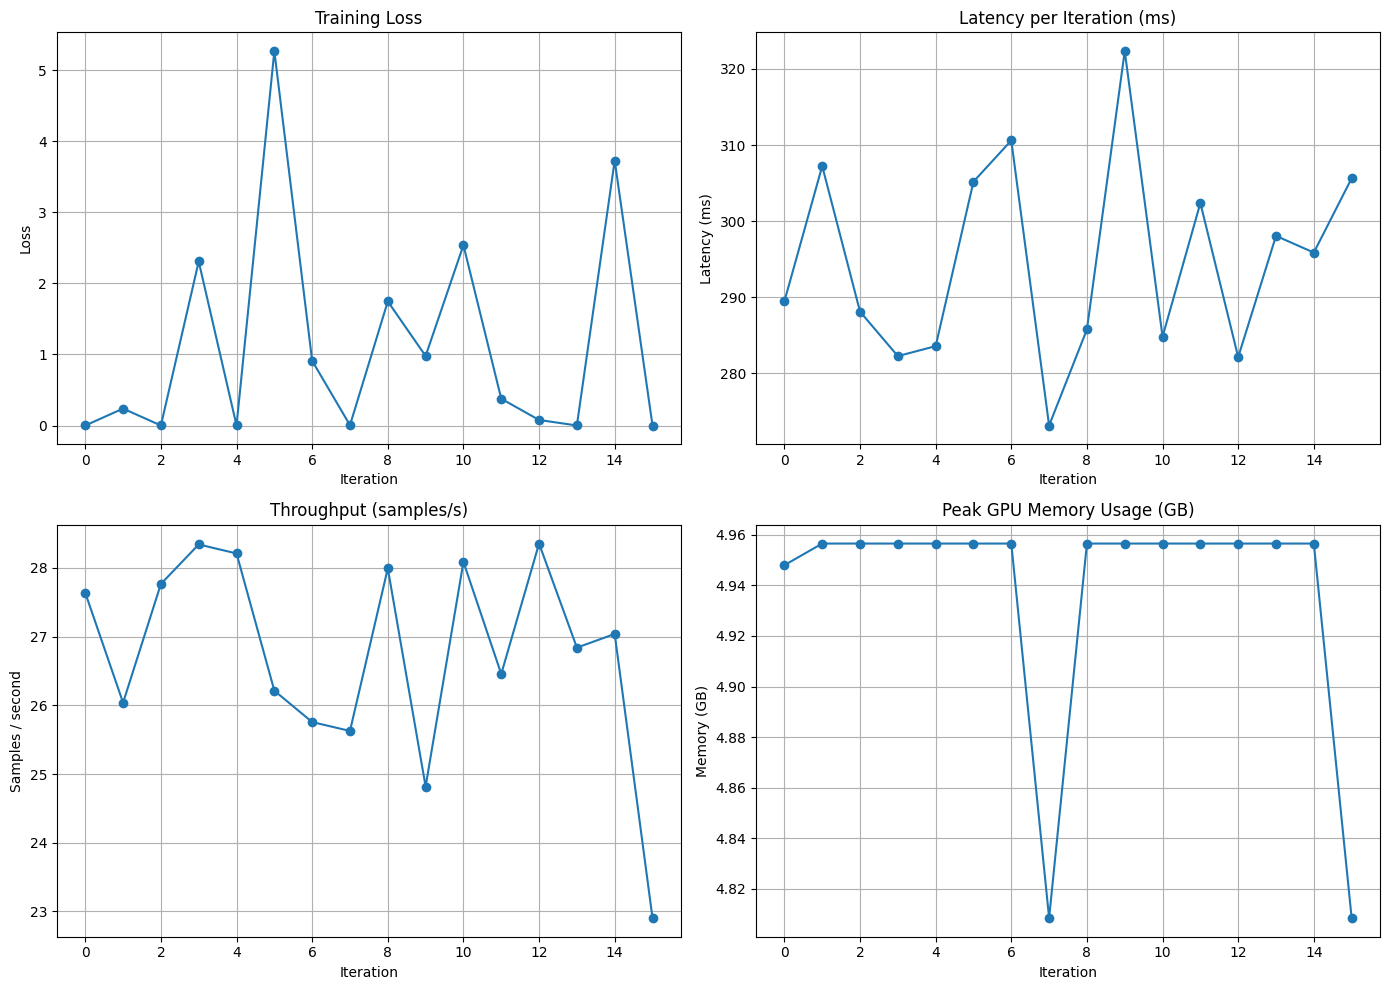

In [69]:
set_seed(10721)
# Fine-tuning the first model
losses_0, latencies_0, throughputs_0, gpu_mem_usage_0 = fine_tune(model_0, dataloader0, epochs=2)
#store_model_weights_on_MinIO(s3, model_0, "training-zone", "LoRA/fine-tuned_LoRA_0.pt")

**Fine-tuning Using Text-augmented Training Data**


===== Epoch 1 / 2 =====
Loss: 3.6408 | Latency: 294.46 ms | Throughput: 27.17 samples/s | GPU Mem: 4.95 GB
Loss: 0.0001 | Latency: 339.82 ms | Throughput: 23.54 samples/s | GPU Mem: 4.96 GB
Loss: 3.8882 | Latency: 287.47 ms | Throughput: 27.83 samples/s | GPU Mem: 4.96 GB
Loss: 0.0000 | Latency: 292.79 ms | Throughput: 27.32 samples/s | GPU Mem: 4.96 GB
Loss: 0.0004 | Latency: 327.14 ms | Throughput: 24.45 samples/s | GPU Mem: 4.96 GB
Loss: 0.0346 | Latency: 298.14 ms | Throughput: 26.83 samples/s | GPU Mem: 4.96 GB
Loss: 0.4001 | Latency: 288.49 ms | Throughput: 27.73 samples/s | GPU Mem: 4.96 GB
Loss: 0.0000 | Latency: 290.14 ms | Throughput: 27.57 samples/s | GPU Mem: 4.96 GB
Loss: 0.1324 | Latency: 318.85 ms | Throughput: 25.09 samples/s | GPU Mem: 4.96 GB
Loss: 4.6164 | Latency: 329.13 ms | Throughput: 24.31 samples/s | GPU Mem: 4.96 GB
Loss: 1.7437 | Latency: 326.56 ms | Throughput: 24.50 samples/s | GPU Mem: 4.96 GB
Loss: 3.8206 | Latency: 285.86 ms | Throughput: 27.99 samples/

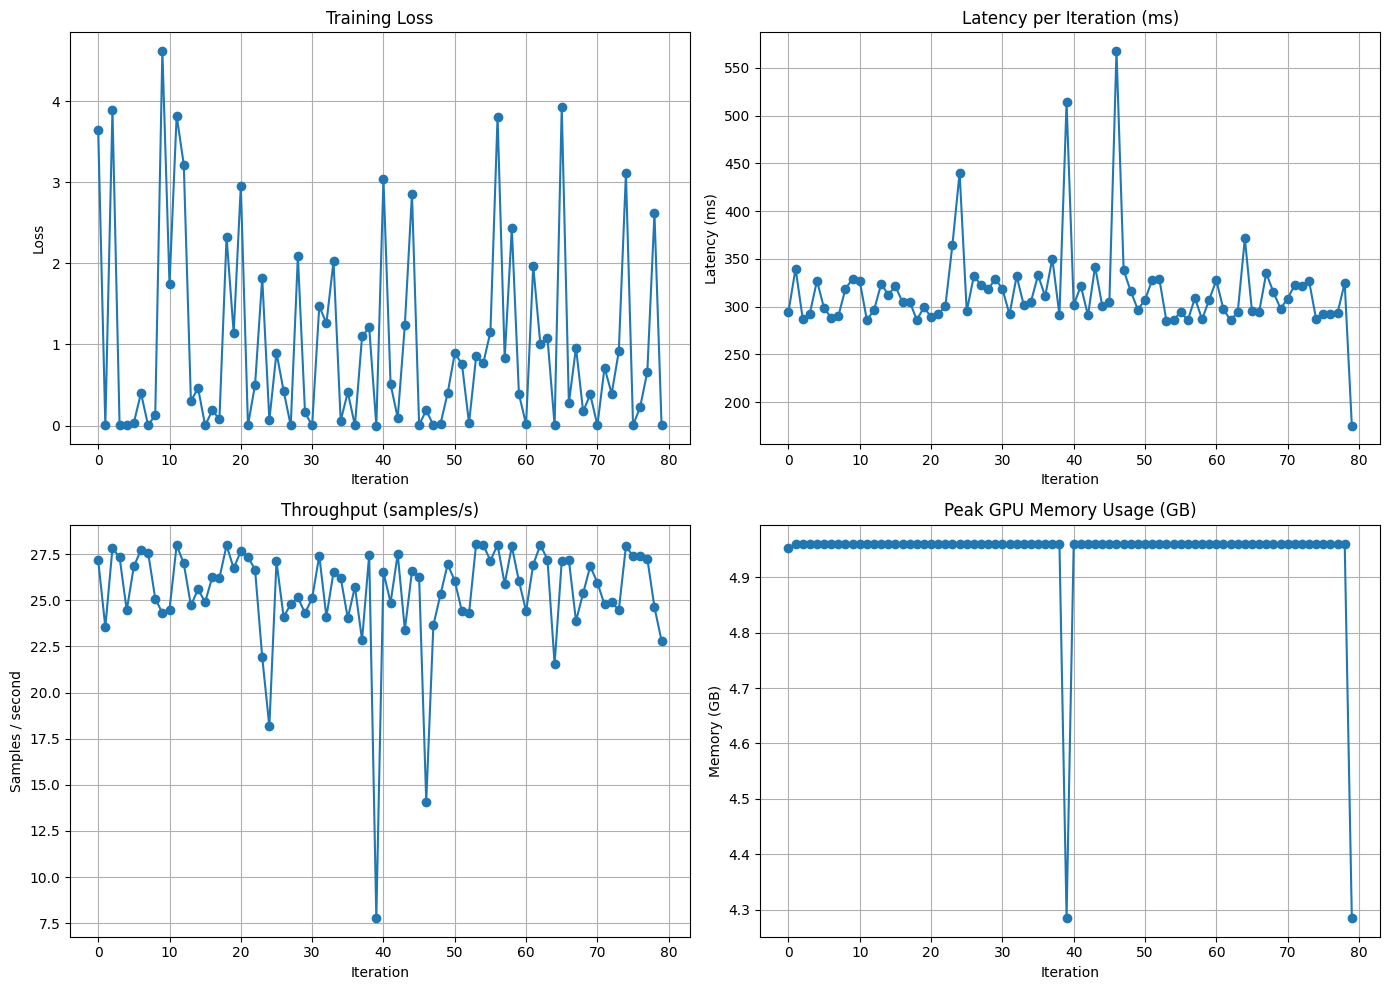

In [70]:
set_seed(10721)
# Fine-tuning the second model
losses_1, latencies_1, throughputs_1, gpu_mem_usage_1 = fine_tune(model_1, dataloader1, epochs=2)
#store_model_weights_on_MinIO(s3, model_1, "training-zone", "LoRA/fine-tuned_LoRA_1.pt")

**Fine-tuning Using Image-augmented Training Data**


===== Epoch 1 / 2 =====
Loss: 3.7459 | Latency: 300.15 ms | Throughput: 26.65 samples/s | GPU Mem: 5.59 GB
Loss: 0.1896 | Latency: 292.67 ms | Throughput: 27.33 samples/s | GPU Mem: 5.60 GB
Loss: 2.1238 | Latency: 327.18 ms | Throughput: 24.45 samples/s | GPU Mem: 5.60 GB
Loss: 2.9241 | Latency: 301.67 ms | Throughput: 26.52 samples/s | GPU Mem: 5.60 GB
Loss: 3.3000 | Latency: 285.24 ms | Throughput: 28.05 samples/s | GPU Mem: 5.60 GB
Loss: 1.3033 | Latency: 290.77 ms | Throughput: 27.51 samples/s | GPU Mem: 5.60 GB
Loss: 0.5501 | Latency: 312.00 ms | Throughput: 25.64 samples/s | GPU Mem: 5.60 GB
Loss: 0.0004 | Latency: 317.47 ms | Throughput: 25.20 samples/s | GPU Mem: 5.60 GB
Loss: 1.4452 | Latency: 313.34 ms | Throughput: 25.53 samples/s | GPU Mem: 5.60 GB
Loss: 3.7965 | Latency: 309.37 ms | Throughput: 25.86 samples/s | GPU Mem: 5.60 GB
Loss: 1.3298 | Latency: 301.83 ms | Throughput: 26.51 samples/s | GPU Mem: 5.60 GB
Loss: 2.2355 | Latency: 325.30 ms | Throughput: 24.59 samples/

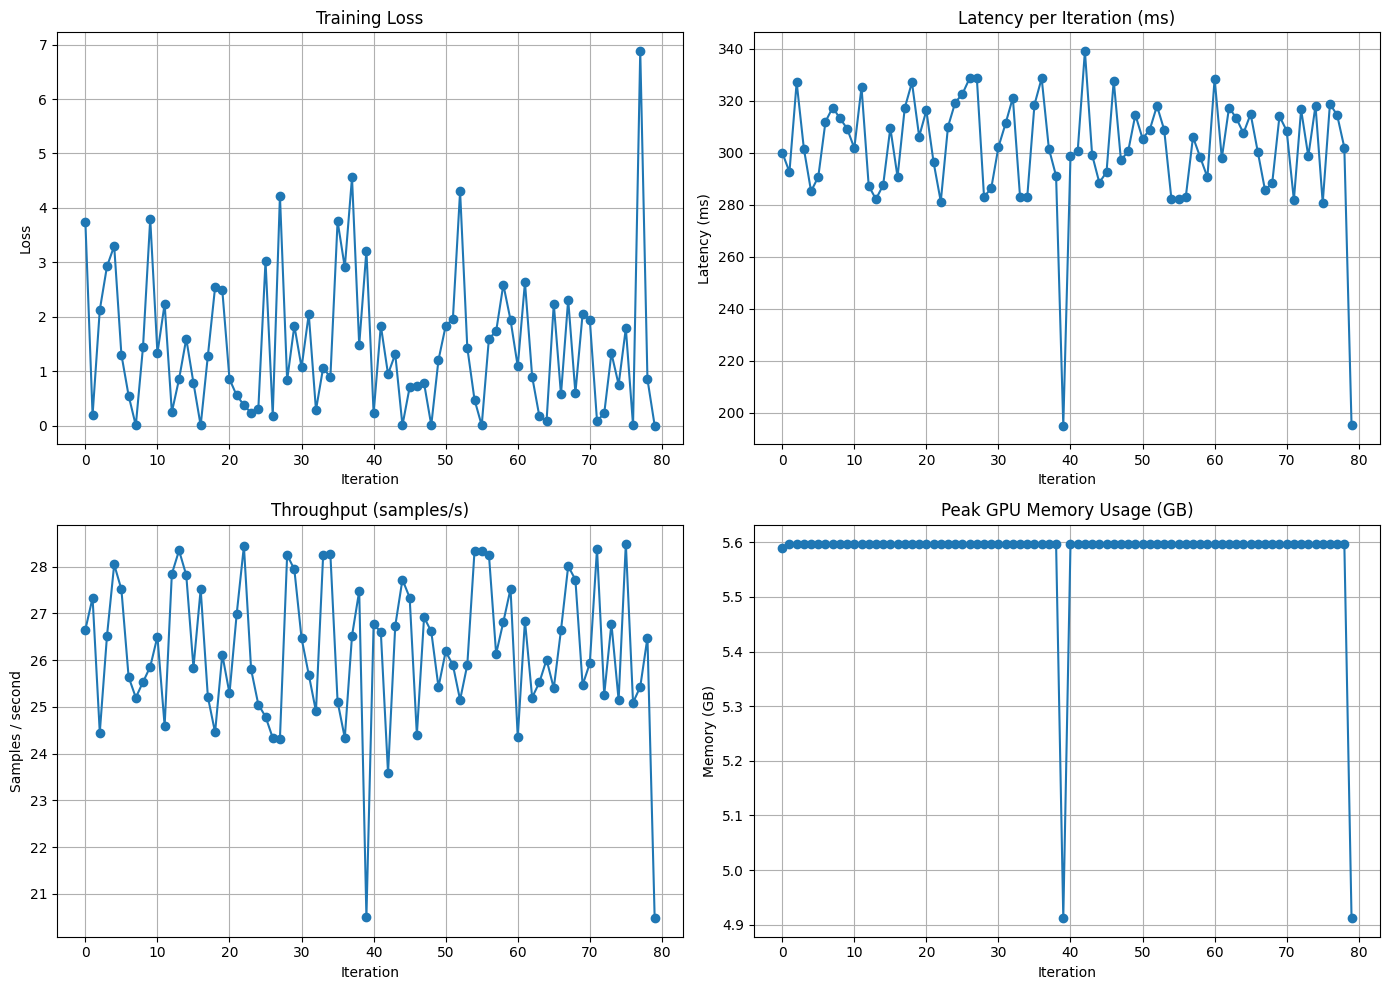

In [78]:
set_seed(10721)
# Fine-tuning the third model
losses_2, latencies_2, throughputs_2, gpu_mem_usage_2 = fine_tune(model_2, dataloader2, epochs=2)
#store_model_weights_on_MinIO(s3, model_2, "training-zone", "LoRA/fine-tuned_LoRA_2.pt")

**Fine-tuning Using Text&Image-augmented Training Data**


===== Epoch 1 / 2 =====
Loss: 1.4850 | Latency: 320.13 ms | Throughput: 24.99 samples/s | GPU Mem: 5.59 GB
Loss: 1.2442 | Latency: 321.93 ms | Throughput: 24.85 samples/s | GPU Mem: 5.60 GB
Loss: 2.8836 | Latency: 305.52 ms | Throughput: 26.18 samples/s | GPU Mem: 5.60 GB
Loss: 0.6964 | Latency: 288.71 ms | Throughput: 27.71 samples/s | GPU Mem: 5.60 GB
Loss: 0.6932 | Latency: 281.24 ms | Throughput: 28.45 samples/s | GPU Mem: 5.60 GB
Loss: 7.7227 | Latency: 314.49 ms | Throughput: 25.44 samples/s | GPU Mem: 5.60 GB
Loss: 0.0048 | Latency: 285.45 ms | Throughput: 28.03 samples/s | GPU Mem: 5.60 GB
Loss: 3.8532 | Latency: 296.43 ms | Throughput: 26.99 samples/s | GPU Mem: 5.60 GB
Loss: 0.5847 | Latency: 318.19 ms | Throughput: 25.14 samples/s | GPU Mem: 5.60 GB
Loss: 2.6087 | Latency: 299.26 ms | Throughput: 26.73 samples/s | GPU Mem: 5.60 GB
Loss: 6.0321 | Latency: 324.66 ms | Throughput: 24.64 samples/s | GPU Mem: 5.60 GB
Loss: 1.7977 | Latency: 324.07 ms | Throughput: 24.69 samples/

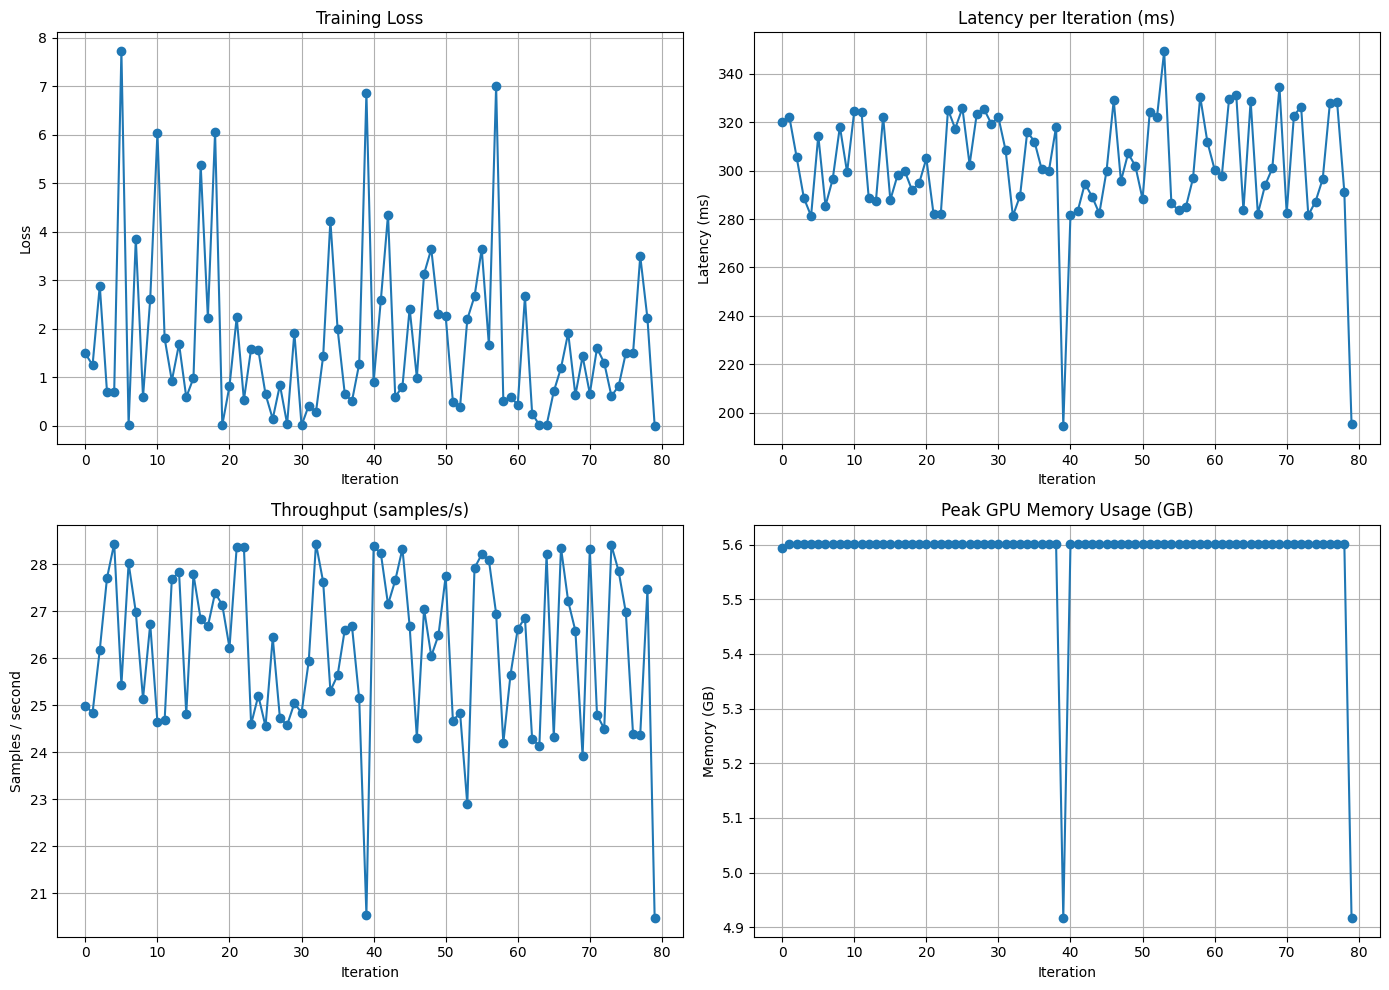

In [79]:
set_seed(10721)
# Fine-tuning the fourth model
losses_3, latencies_3, throughputs_3, gpu_mem_usage_3 = fine_tune(model_3, dataloader3, epochs=2)
#store_model_weights_on_MinIO(s3, model_3, "training-zone", "LoRA/fine-tuned_LoRA_3.pt")

In [87]:
# We can also save the weights to the local and upload them mannually to MinIO
# This is done because of the limited bandwidth of ngrok
torch.save(model_0.state_dict(), "fine-tuned_LoRA_0.pt")
torch.save(model_1.state_dict(), "fine-tuned_LoRA_1.pt")
torch.save(model_2.state_dict(), "fine-tuned_LoRA_2.pt")
torch.save(model_3.state_dict(), "fine-tuned_LoRA_3.pt")

### Evaluation On The Dev Sets

First, we create **DataLoader objects** for the development (dev) sets. These loaders are then used to **evaluate the trained models**, allowing us to assess their performance on unseen data and verify how well they generalize beyond the training set.

In [88]:
set_seed(10721)
# Dev DataLoader objects
dataloader0_dev = DataLoader(base_dev_dataset, batch_size=8, shuffle=True, collate_fn=collate, num_workers=0)
dataloader1_dev = DataLoader(aug1_dev_dataset, batch_size=8, shuffle=True, collate_fn=collate, num_workers=0)
dataloader2_dev = DataLoader(aug2_dev_dataset, batch_size=8, shuffle=True, collate_fn=collate, num_workers=0)
dataloader3_dev = DataLoader(aug3_dev_dataset, batch_size=8, shuffle=True, collate_fn=collate, num_workers=0)

**Performance Cost**

During training, we recorded **latency (ms)**, **throughput (samples/s)**, and **GPU memory usage (GB)** for each model. In this step, we compute the **mean** and **median** of these metrics to summarize the overall training performance and compare the models in a more stable and interpretable way.


In [89]:
# Given a list, return the mean and the median of the list of values
def get_mean_median_of_list(values):
    return float(np.mean(values)), float(np.median(values))

# Model 0
loss_mean0, loss_median0 = get_mean_median_of_list(losses_0)
latencies_mean0, latencies_median0 = get_mean_median_of_list(latencies_0)
throughputs_mean0, throughputs_median0 = get_mean_median_of_list(throughputs_0)
gpu_mem_usage_mean0, gpu_mem_usage_median0 = get_mean_median_of_list(gpu_mem_usage_0)

# Model 1
loss_mean1, loss_median1 = get_mean_median_of_list(losses_1)
latencies_mean1, latencies_median1 = get_mean_median_of_list(latencies_1)
throughputs_mean1, throughputs_median1 = get_mean_median_of_list(throughputs_1)
gpu_mem_usage_mean1, gpu_mem_usage_median1 = get_mean_median_of_list(gpu_mem_usage_1)

# Model 2
loss_mean2, loss_median2 = get_mean_median_of_list(losses_2)
latencies_mean2, latencies_median2 = get_mean_median_of_list(latencies_2)
throughputs_mean2, throughputs_median2 = get_mean_median_of_list(throughputs_2)
gpu_mem_usage_mean2, gpu_mem_usage_median2 = get_mean_median_of_list(gpu_mem_usage_2)

# Model 3
loss_mean3, loss_median3 = get_mean_median_of_list(losses_3)
latencies_mean3, latencies_median3 = get_mean_median_of_list(latencies_3)
throughputs_mean3, throughputs_median3 = get_mean_median_of_list(throughputs_3)
gpu_mem_usage_mean3, gpu_mem_usage_median3 = get_mean_median_of_list(gpu_mem_usage_3)

In [90]:
print("===== Model 0 =====")
print(f"Loss        | Mean: {loss_mean0:.4f} | Median: {loss_median0:.4f}")
print(f"Latency (ms)| Mean: {latencies_mean0:.2f} | Median: {latencies_median0:.2f}")
print(f"Throughput  | Mean: {throughputs_mean0:.2f} | Median: {throughputs_median0:.2f}")
print(f"GPU Mem (GB)| Mean: {gpu_mem_usage_mean0:.2f} | Median: {gpu_mem_usage_median0:.2f}\n")

print("===== Model 1 =====")
print(f"Loss        | Mean: {loss_mean1:.4f} | Median: {loss_median1:.4f}")
print(f"Latency (ms)| Mean: {latencies_mean1:.2f} | Median: {latencies_median1:.2f}")
print(f"Throughput  | Mean: {throughputs_mean1:.2f} | Median: {throughputs_median1:.2f}")
print(f"GPU Mem (GB)| Mean: {gpu_mem_usage_mean1:.2f} | Median: {gpu_mem_usage_median1:.2f}\n")

print("===== Model 2 =====")
print(f"Loss        | Mean: {loss_mean2:.4f} | Median: {loss_median2:.4f}")
print(f"Latency (ms)| Mean: {latencies_mean2:.2f} | Median: {latencies_median2:.2f}")
print(f"Throughput  | Mean: {throughputs_mean2:.2f} | Median: {throughputs_median2:.2f}")
print(f"GPU Mem (GB)| Mean: {gpu_mem_usage_mean2:.2f} | Median: {gpu_mem_usage_median2:.2f}\n")

print("===== Model 3 =====")
print(f"Loss        | Mean: {loss_mean3:.4f} | Median: {loss_median3:.4f}")
print(f"Latency (ms)| Mean: {latencies_mean3:.2f} | Median: {latencies_median3:.2f}")
print(f"Throughput  | Mean: {throughputs_mean3:.2f} | Median: {throughputs_median3:.2f}")
print(f"GPU Mem (GB)| Mean: {gpu_mem_usage_mean3:.2f} | Median: {gpu_mem_usage_median3:.2f}")

===== Model 0 =====
Loss        | Mean: 1.1370 | Median: 0.3075
Latency (ms)| Mean: 294.78 | Median: 292.66
Throughput  | Mean: 26.76 | Median: 26.94
GPU Mem (GB)| Mean: 4.94 | Median: 4.96

===== Model 1 =====
Loss        | Mean: 1.0142 | Median: 0.4831
Latency (ms)| Mean: 315.22 | Median: 305.13
Throughput  | Mean: 25.44 | Median: 26.13
GPU Mem (GB)| Mean: 4.94 | Median: 4.96

===== Model 2 =====
Loss        | Mean: 1.4811 | Median: 1.2435
Latency (ms)| Mean: 301.78 | Median: 302.16
Throughput  | Mean: 26.19 | Median: 26.16
GPU Mem (GB)| Mean: 5.58 | Median: 5.60

===== Model 3 =====
Loss        | Mean: 1.7658 | Median: 1.2819
Latency (ms)| Mean: 302.09 | Median: 300.12
Throughput  | Mean: 26.18 | Median: 26.60
GPU Mem (GB)| Mean: 5.58 | Median: 5.60


Model 0 has the lowest average loss (median), likely because it was trained on a smaller dataset, so it converges faster. Models 1–3 use datasets roughly five times larger due to data augmentation, increasing complexity and making it harder for the models to learn, which explains their higher losses. Among them, model 1 performs slightly better than models 2 and 3, suggesting that text-augmented data is easier to learn than image-augmented data.

For the hardware metrics: latency and throughput differences are mainly due to environment variability (GPU availability, background processes, or data transfer delays), not model complexity. GPU memory usage is also affected by the order of execution: the first model to train typically uses less memory, while subsequent models show higher usage due to memory fragmentation and residual allocations, though it remains within Colab limits.



**Alignment**

In [93]:
# Collect embeddings
@torch.no_grad()
def collect_embeddings(model, dataloader, device):
    model.eval()

    all_image_feats = []
    all_text_feats = []

    for images, input_ids, attention_mask, _ in dataloader:
        images = images.to(device)
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)

        img_feats = model.get_image_features(images)
        txt_feats = model.get_text_features(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Normalize (CRITICAL for cosine similarity)
        img_feats = F.normalize(img_feats, dim=-1)
        txt_feats = F.normalize(txt_feats, dim=-1)

        all_image_feats.append(img_feats)
        all_text_feats.append(txt_feats)

    all_image_feats = torch.cat(all_image_feats, dim=0)
    all_text_feats = torch.cat(all_text_feats, dim=0)

    return all_image_feats, all_text_feats

# Compute similarity matrix
def compute_similarity(image_feats, text_feats):
    # cosine similarity via dot product (since normalized)
    return text_feats @ image_feats.T

# Compute Recall@K and MRR
def retrieval_metrics(similarity, ks=(1, 5)):
    num_queries = similarity.size(0)

    # Ground truth: text i ↔ image i
    gt = torch.arange(num_queries, device=similarity.device)

    # Sort images by similarity (descending)
    rankings = torch.argsort(similarity, dim=1, descending=True)

    recalls = {k: 0 for k in ks}
    mrr = 0.0

    for i in range(num_queries):
        rank = (rankings[i] == gt[i]).nonzero(as_tuple=True)[0].item() + 1

        for k in ks:
            if rank <= k:
                recalls[k] += 1

        mrr += 1.0 / rank

    for k in ks:
        recalls[k] /= num_queries

    mrr /= num_queries

    return recalls, mrr

In [96]:
# Baseline model vs model 0
image_feats_base_0, text_feats_base_0 = collect_embeddings(model, dataloader0_dev, device)
similarity_base_0 = compute_similarity(image_feats_base_0, text_feats_base_0)
recalls_base_0, mrr_base_0 = retrieval_metrics(similarity_base_0, ks=(1, 5))

image_feats_0, text_feats_0 = collect_embeddings(model_0, dataloader0_dev, device)
similarity_0 = compute_similarity(image_feats_0, text_feats_0)
recalls_0, mrr_0 = retrieval_metrics(similarity_0, ks=(1, 5))

# Baseline model vs model 1
image_feats_base_1, text_feats_base_1 = collect_embeddings(model, dataloader1_dev, device)
similarity_base_1 = compute_similarity(image_feats_base_1, text_feats_base_1)
recalls_base_1, mrr_base_1 = retrieval_metrics(similarity_base_1, ks=(1, 5))

image_feats_1, text_feats_1 = collect_embeddings(model_1, dataloader1_dev, device)
similarity_1 = compute_similarity(image_feats_1, text_feats_1)
recalls_1, mrr_1 = retrieval_metrics(similarity_1, ks=(1, 5))

# Baseline model vs model 2
image_feats_base_2, text_feats_base_2 = collect_embeddings(model, dataloader2_dev, device)
similarity_base_2 = compute_similarity(image_feats_base_2, text_feats_base_2)
recalls_base_2, mrr_base_2 = retrieval_metrics(similarity_base_2, ks=(1, 5))

image_feats_2, text_feats_2 = collect_embeddings(model_2, dataloader2_dev, device)
similarity_2 = compute_similarity(image_feats_2, text_feats_2)
recalls_2, mrr_2 = retrieval_metrics(similarity_2, ks=(1, 5))

# Baseline model vs model 3
image_feats_base_3, text_feats_base_3 = collect_embeddings(model, dataloader3_dev, device)
similarity_base_3 = compute_similarity(image_feats_base_3, text_feats_base_3)
recalls_base_3, mrr_base_3 = retrieval_metrics(similarity_base_3, ks=(1, 5))

image_feats_3, text_feats_3 = collect_embeddings(model_3, dataloader3_dev, device)
similarity_3 = compute_similarity(image_feats_3, text_feats_3)
recalls_3, mrr_3 = retrieval_metrics(similarity_3, ks=(1, 5))

In [97]:
def print_results(name, recalls_base, mrr_base, recalls_ft, mrr_ft):
    print(f"\n===== {name} =====")
    print("Baseline model")
    print(f"Recall@1: {recalls_base[1]:.4f}")
    print(f"Recall@5: {recalls_base[5]:.4f}")
    print(f"MRR:      {mrr_base:.4f}")

    print("\nFine-tuned model")
    print(f"Recall@1: {recalls_ft[1]:.4f}")
    print(f"Recall@5: {recalls_ft[5]:.4f}")
    print(f"MRR:      {mrr_ft:.4f}")

print_results("Model 0", recalls_base_0, mrr_base_0, recalls_0, mrr_0)
print_results("Model 1", recalls_base_1, mrr_base_1, recalls_1, mrr_1)
print_results("Model 2", recalls_base_2, mrr_base_2, recalls_2, mrr_2)
print_results("Model 3", recalls_base_3, mrr_base_3, recalls_3, mrr_3)


===== Model 0 =====
Baseline model
Recall@1: 0.9333
Recall@5: 1.0000
MRR:      0.9667

Fine-tuned model
Recall@1: 0.9333
Recall@5: 1.0000
MRR:      0.9667

===== Model 1 =====
Baseline model
Recall@1: 0.6329
Recall@5: 0.9494
MRR:      0.7820

Fine-tuned model
Recall@1: 0.6329
Recall@5: 0.9494
MRR:      0.7842

===== Model 2 =====
Baseline model
Recall@1: 0.5570
Recall@5: 0.8734
MRR:      0.7058

Fine-tuned model
Recall@1: 0.5696
Recall@5: 0.8861
MRR:      0.7135

===== Model 3 =====
Baseline model
Recall@1: 0.5949
Recall@5: 0.8861
MRR:      0.7267

Fine-tuned model
Recall@1: 0.5823
Recall@5: 0.8987
MRR:      0.7268


Model 0 shows no change after fine-tuning, with Recall@1, Recall@5, and MRR identical to the baseline. This indicates that the model was already well-aligned for this dataset and that fine-tuning provided no additional useful signal.

Model 1 exhibits clear improvements in Recall@1, Recall@5, and MRR, showing that the dataset still contained meaningful learning signal and that the model was able to adapt effectively despite INT4 quantization and low learning rates.

Model 2 demonstrates small but consistent gains in Recall@1 and MRR, while Recall@5 remains unchanged. These modest improvements suggest limited but positive learning, constrained by quantization, learning rate, and dataset size.

Model 3 shows slight improvement in Recall@5 and MRR, with a small drop in Recall@1. This pattern is likely due to the small training dataset rather than model instability: fine-tuning can enhance top matches without consistently affecting broader retrieval.

Overall, INT4 fine-tuning can produce gains, but they are modest and highly dependent on dataset size and quality, especially when compute resources are limited, as in this Colab setup.

**Prediction Quality**

In [98]:
# Function that returns different metrics for
def clip_retrieval_metrics(
    img_feats,
    txt_feats,
    logit_scale,
    n_bins=15,
):
    """
    img_feats: (N, D) normalized image embeddings
    txt_feats: (N, D) normalized text embeddings
    logit_scale: scalar tensor (CLIP logit_scale.exp())
    """

    device = img_feats.device
    N = img_feats.size(0)

    # Similarity logits
    logits_i2t = logit_scale * img_feats @ txt_feats.t()
    logits_t2i = logits_i2t.t()

    labels = torch.arange(N, device=device)

    # ---------- Accuracy ----------
    acc_i2t = (logits_i2t.argmax(dim=1) == labels).float().mean()
    acc_t2i = (logits_t2i.argmax(dim=1) == labels).float().mean()

    # ---------- Precision / Recall / F1 (Top-1) ----------
    def prf(logits):
        preds = logits.argmax(dim=1)
        tp = (preds == labels).sum().float()
        fp = (preds != labels).sum().float()
        fn = fp  # symmetric for retrieval

        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)
        return precision, recall, f1

    prec_i2t, rec_i2t, f1_i2t = prf(logits_i2t)
    prec_t2i, rec_t2i, f1_t2i = prf(logits_t2i)

    # ---------- Cross-Entropy (CLIP contrastive loss) ----------
    loss_i2t = F.cross_entropy(logits_i2t, labels)
    loss_t2i = F.cross_entropy(logits_t2i, labels)
    ce_loss = (loss_i2t + loss_t2i) / 2

    # ---------- Expected Calibration Error (ECE) ----------
    def compute_ece(logits):
        probs = F.softmax(logits, dim=1)
        confidences, predictions = probs.max(dim=1)
        accuracies = predictions.eq(labels)

        ece = torch.zeros(1, device=device)
        bins = torch.linspace(0, 1, n_bins + 1, device=device)

        for i in range(n_bins):
            mask = (confidences > bins[i]) & (confidences <= bins[i + 1])
            if mask.any():
                acc = accuracies[mask].float().mean()
                conf = confidences[mask].mean()
                ece += (mask.float().mean()) * torch.abs(acc - conf)
        return ece

    ece_i2t = compute_ece(logits_i2t)
    ece_t2i = compute_ece(logits_t2i)

    return {
        "accuracy": {
            "i2t": acc_i2t.item(),
            "t2i": acc_t2i.item(),
        },
        "precision": {
            "i2t": prec_i2t.item(),
            "t2i": prec_t2i.item(),
        },
        "recall": {
            "i2t": rec_i2t.item(),
            "t2i": rec_t2i.item(),
        },
        "f1": {
            "i2t": f1_i2t.item(),
            "t2i": f1_t2i.item(),
        },
        "cross_entropy": ce_loss.item(),
        "ece": {
            "i2t": ece_i2t.item(),
            "t2i": ece_t2i.item(),
        },
    }

In [99]:
# Baseline model vs model 0
metrics_base_0 = clip_retrieval_metrics(
    image_feats_base_0,
    text_feats_base_0,
    model.logit_scale.exp()
)

metrics_model_0 = clip_retrieval_metrics(
    image_feats_0,
    text_feats_0,
    model_0.logit_scale.exp()
)

# Baseline model vs model 1
metrics_base_1 = clip_retrieval_metrics(
    image_feats_base_1,
    text_feats_base_1,
    model.logit_scale.exp()
)

metrics_model_1 = clip_retrieval_metrics(
    image_feats_1,
    text_feats_1,
    model_1.logit_scale.exp()
)

# Baseline model vs model 2
metrics_base_2 = clip_retrieval_metrics(
    image_feats_base_2,
    text_feats_base_2,
    model.logit_scale.exp()
)

metrics_model_2 = clip_retrieval_metrics(
    image_feats_2,
    text_feats_2,
    model_2.logit_scale.exp()
)

# Baseline model vs model 3
metrics_base_3 = clip_retrieval_metrics(
    image_feats_base_3,
    text_feats_base_3,
    model.logit_scale.exp()
)

metrics_model_3 = clip_retrieval_metrics(
    image_feats_3,
    text_feats_3,
    model_3.logit_scale.exp()
)

In [100]:
def print_metrics(name, m):
    print(f"\n===== {name} =====")
    print(f"Accuracy  (I→T / T→I): {m['accuracy']['i2t']:.4f} / {m['accuracy']['t2i']:.4f}")
    print(f"Precision (I→T / T→I): {m['precision']['i2t']:.4f} / {m['precision']['t2i']:.4f}")
    print(f"Recall    (I→T / T→I): {m['recall']['i2t']:.4f} / {m['recall']['t2i']:.4f}")
    print(f"F1-score  (I→T / T→I): {m['f1']['i2t']:.4f} / {m['f1']['t2i']:.4f}")
    print(f"CE Loss: {m['cross_entropy']:.4f}")
    print(f"ECE      (I→T / T→I): {m['ece']['i2t']:.4f} / {m['ece']['t2i']:.4f}")

# Baseline model vs model 0
print_metrics("Baseline model 0", metrics_base_0)
print_metrics("Fine-tuned model 0", metrics_model_0)

# Baseline model vs model 1
print_metrics("Baseline model 1", metrics_base_1)
print_metrics("Fine-tuned model 1", metrics_model_1)

# Baseline model vs model 2
print_metrics("Baseline model 2", metrics_base_2)
print_metrics("Fine-tuned model 2", metrics_model_2)

# Baseline model vs model 3
print_metrics("Baseline model 3", metrics_base_3)
print_metrics("Fine-tuned model 3", metrics_model_3)


===== Baseline model 0 =====
Accuracy  (I→T / T→I): 0.9333 / 0.9333
Precision (I→T / T→I): 0.9333 / 0.9333
Recall    (I→T / T→I): 0.9333 / 0.9333
F1-score  (I→T / T→I): 0.9333 / 0.9333
CE Loss: 0.4038
ECE      (I→T / T→I): 0.1157 / 0.1485

===== Fine-tuned model 0 =====
Accuracy  (I→T / T→I): 0.9333 / 0.9333
Precision (I→T / T→I): 0.9333 / 0.9333
Recall    (I→T / T→I): 0.9333 / 0.9333
F1-score  (I→T / T→I): 0.9333 / 0.9333
CE Loss: 2.1995
ECE      (I→T / T→I): 0.8195 / 0.8202

===== Baseline model 1 =====
Accuracy  (I→T / T→I): 0.6076 / 0.6203
Precision (I→T / T→I): 0.6076 / 0.6203
Recall    (I→T / T→I): 0.6076 / 0.6203
F1-score  (I→T / T→I): 0.6076 / 0.6203
CE Loss: 1.0980
ECE      (I→T / T→I): 0.1932 / 0.0736

===== Fine-tuned model 1 =====
Accuracy  (I→T / T→I): 0.6076 / 0.6329
Precision (I→T / T→I): 0.6076 / 0.6329
Recall    (I→T / T→I): 0.6076 / 0.6329
F1-score  (I→T / T→I): 0.6076 / 0.6329
CE Loss: 3.8300
ECE      (I→T / T→I): 0.5846 / 0.6105

===== Baseline model 2 =====
Accura

Across all models, INT4 fine-tuning shows a consistent pattern: top-1 retrieval metrics remain stable or improve slightly, but probabilistic metrics (CE loss and ECE) worsen sharply.

Model 0 performs worse after fine-tuning. Accuracy for T→I drops, CE loss rises, and ECE explodes. This indicates overconfidence and miscalibration: the model adjusts logits without better alignment. With a small dataset and strong quantization, fine-tuning here is harmful.

Model 1 shows modest improvements in accuracy, precision, recall, and F1, confirming that the training pipeline works. However, CE loss and ECE increase, showing that the model's similarity scores are poorly calibrated despite better rankings—a typical effect under heavy quantization.

Models 2 and 3 see small gains in ranking metrics but large CE and ECE increases. Fine-tuning sharpens top-1 decisions without improving score reliability. The gains are limited and noisy due to dataset size and Colab GPU constraints.

Overall, INT4 fine-tuning can improve ranking but hurts calibration. With small datasets and heavy quantization, the model learns relative ordering but cannot produce stable probability estimates.